## NTU 标准化滞后项与自相关分析

前面的滞后相关性分析主要研究其他水质和工艺变量与当前出厂水浊度 `NTU` 的关系。为了进一步判断 `NTU` 本身是否具有时间连续性，本节不是对相关系数本身进行标准化，而是先对 `NTU` 原始序列进行 Z-score 标准化，得到 `NTU_z`，再构造标准化后的滞后项：

$$
NTU_{z,t-k}, \quad k=0,1,\ldots,12
$$

随后计算：

$$
corr(NTU_{z,t-k}, NTU_{z,t})
$$

由于数据采样间隔为 2 小时，因此 `lag1` 表示 2 小时前的标准化 NTU，`lag12` 表示 24 小时前的标准化 NTU。

需要注意的是，相关系数本身已经是无量纲指标，因此标准化不会显著改变 Pearson/Spearman 相关系数的数值。这里进行标准化的重点是生成标准化滞后特征 `NTU_z_lagk`，便于后续建模、画图和周期性分析。

### 1. 构造标准化 NTU 滞后项并计算自相关系数

本节首先按照时间顺序排列数据，并将 `NTU` 转换为数值型变量。随后对 `NTU` 进行 Z-score 标准化：

$$
NTU_z = \frac{NTU - \mu_{NTU}}{\sigma_{NTU}}
$$

在此基础上构造 `lag0` 至 `lag12` 的标准化滞后项：

```text
NTU_z_lag0
NTU_z_lag1
...
NTU_z_lag12
```

最后计算每个标准化滞后项与当前标准化 NTU 的 Pearson 和 Spearman 相关系数。这里标准化的是滞后项对应的变量值，而不是对相关系数本身再次标准化。

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/problem1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

possible_paths = [
    Path("data/merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("../data/merged.xlsx"),
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Cannot find merged.xlsx. Please check your data path.")

print("Using data file:", DATA_PATH)

df = pd.read_excel(DATA_PATH)

print("Columns:")
print(df.columns.tolist())

# 处理 DATE
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# 处理 TIME
def normalize_time_to_string(x):
    if pd.isna(x):
        return np.nan
    
    # 如果已经是 datetime.time 类型
    if hasattr(x, "hour") and hasattr(x, "minute"):
        return f"{x.hour:02d}:{x.minute:02d}:00"
    
    s = str(x).strip()
    
    # 处理类似 1900-01-01 07:00:00 的情况
    if "1900-01-01" in s:
        s = s.replace("1900-01-01", "").strip()
    
    # 处理 700, 0700, 900, 0900 这类格式
    if s.replace(".0", "").isdigit():
        s = s.replace(".0", "")
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}:00"
    
    # 处理 07:00, 07:00:00 这类格式
    t = pd.to_datetime(s, errors="coerce")
    if pd.isna(t):
        return np.nan
    
    return t.strftime("%H:%M:%S")

df["TIME_STR"] = df["TIME"].apply(normalize_time_to_string)

# 构造 DATETIME
df["DATETIME"] = pd.to_datetime(
    df["DATE"].dt.strftime("%Y-%m-%d") + " " + df["TIME_STR"],
    errors="coerce"
)

# 按时间排序
df = df.sort_values("DATETIME").reset_index(drop=True)

print("Data shape:", df.shape)
print("DATETIME missing:", df["DATETIME"].isna().sum())
print("Time range:", df["DATETIME"].min(), "to", df["DATETIME"].max())

df[["DATE", "TIME", "TIME_STR", "DATETIME"]].head(15)

Using data file: ..\data\merged.xlsx
Columns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
Data shape: (5460, 20)
DATETIME missing: 0
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00


,DATE,TIME,TIME_STR,DATETIME
0,2025-01-01,07:00:00,07:00:00,2025-01-01 07:00:00
1,2025-01-01,09:00:00,09:00:00,2025-01-01 09:00:00
2,2025-01-01,11:00:00,11:00:00,2025-01-01 11:00:00
3,2025-01-01,13:00:00,13:00:00,2025-01-01 13:00:00
4,2025-01-01,15:00:00,15:00:00,2025-01-01 15:00:00
5,2025-01-01,17:00:00,17:00:00,2025-01-01 17:00:00
6,2025-01-01,19:00:00,19:00:00,2025-01-01 19:00:00
7,2025-01-01,21:00:00,21:00:00,2025-01-01 21:00:00
8,2025-01-01,23:00:00,23:00:00,2025-01-01 23:00:00
9,2025-01-02,01:00:00,01:00:00,2025-01-02 01:00:00


### 1.1 NTU 序列标准化

这里先将原始 `NTU` 序列标准化为 `NTU_z`。后续所有 `NTU` 滞后项都基于 `NTU_z` 构造，即 `NTU_z_lag1`、`NTU_z_lag2` 等。

In [4]:
# =========================
# NTU standardization before lag construction
# 标准化的是 NTU 变量值，后续再基于 NTU_z 构造 lag 特征
# =========================

df["NTU"] = pd.to_numeric(df["NTU"], errors="coerce")

ntu_mean = df["NTU"].mean(skipna=True)
ntu_std = df["NTU"].std(skipna=True)

df["NTU_z"] = (df["NTU"] - ntu_mean) / ntu_std

ntu_standardized_path = OUTPUT_DIR / "ntu_standardized_series.csv"
df[["DATETIME", "NTU", "NTU_z"]].to_csv(
    ntu_standardized_path,
    index=False,
    encoding="utf-8-sig"
)

print("NTU mean:", ntu_mean)
print("NTU std:", ntu_std)
print("Saved:", ntu_standardized_path)

df[["DATETIME", "NTU", "NTU_z"]].head(10)

NTU mean: 0.4457944964871195
NTU std: 0.6163107063064378
Saved: outputs\problem1\ntu_standardized_series.csv


,DATETIME,NTU,NTU_z
0,2025-01-01 07:00:00,0.12,-0.528621
1,2025-01-01 09:00:00,0.12,-0.528621
2,2025-01-01 11:00:00,0.12,-0.528621
3,2025-01-01 13:00:00,0.11,-0.544846
4,2025-01-01 15:00:00,0.11,-0.544846
5,2025-01-01 17:00:00,0.11,-0.544846
6,2025-01-01 19:00:00,0.11,-0.544846
7,2025-01-01 21:00:00,0.11,-0.544846
8,2025-01-01 23:00:00,0.12,-0.528621
9,2025-01-02 01:00:00,0.12,-0.528621


In [5]:
# =========================
# Construct standardized NTU lag features and calculate autocorrelation
# =========================

max_lag = 12
records = []

# 构造标准化 NTU 的 lag 特征
for lag in range(0, max_lag + 1):
    df[f"NTU_z_lag{lag}"] = df["NTU_z"].shift(lag)

# 保存标准化后的 lag 特征表
lag_feature_cols = ["DATETIME", "NTU", "NTU_z"] + [f"NTU_z_lag{lag}" for lag in range(0, max_lag + 1)]
ntu_z_lag_features = df[lag_feature_cols].copy()

lag_feature_save_path = OUTPUT_DIR / "ntu_standardized_lag_features_lag0_to_lag12.csv"
ntu_z_lag_features.to_csv(lag_feature_save_path, index=False, encoding="utf-8-sig")

print("Saved standardized lag features:", lag_feature_save_path)

# 基于标准化 lag 特征计算自相关
for lag in range(0, max_lag + 1):
    lag_col = f"NTU_z_lag{lag}"

    temp = df[["NTU_z", lag_col]].dropna().copy()
    temp.columns = ["NTU_z_current", "NTU_z_lagged"]

    valid_n = len(temp)

    if valid_n > 0:
        pearson_corr = temp["NTU_z_lagged"].corr(temp["NTU_z_current"], method="pearson")
        spearman_corr = temp["NTU_z_lagged"].corr(temp["NTU_z_current"], method="spearman")
    else:
        pearson_corr = np.nan
        spearman_corr = np.nan

    records.append({
        "lag": lag,
        "lag_hours": lag * 2,
        "lag_feature": lag_col,
        "valid_n": valid_n,
        "pearson_corr": pearson_corr,
        "pearson_abs": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
        "spearman_corr": spearman_corr,
        "spearman_abs": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
    })

ntu_autocorr_df = pd.DataFrame(records)

save_path = OUTPUT_DIR / "ntu_standardized_lag_autocorrelation_lag0_to_lag12.csv"
ntu_autocorr_df.to_csv(save_path, index=False, encoding="utf-8-sig")

print("Saved:", save_path)
display(ntu_z_lag_features.head(10))
ntu_autocorr_df

Saved standardized lag features: outputs\problem1\ntu_standardized_lag_features_lag0_to_lag12.csv
Saved: outputs\problem1\ntu_standardized_lag_autocorrelation_lag0_to_lag12.csv


,DATETIME,NTU,NTU_z,NTU_z_lag0,NTU_z_lag1,NTU_z_lag2,NTU_z_lag3,NTU_z_lag4,NTU_z_lag5,NTU_z_lag6,NTU_z_lag7,NTU_z_lag8,NTU_z_lag9,NTU_z_lag10,NTU_z_lag11,NTU_z_lag12
0,2025-01-01 07:00:00,0.12,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,0.12,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,0.12,-0.528621,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,0.11,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 15:00:00,0.11,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-01-01 17:00:00,0.11,-0.544846,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-01-01 19:00:00,0.11,-0.544846,-0.544846,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN,NaN
7,2025-01-01 21:00:00,0.11,-0.544846,-0.544846,-0.544846,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN,NaN
8,2025-01-01 23:00:00,0.12,-0.528621,-0.528621,-0.544846,-0.544846,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN,NaN
9,2025-01-02 01:00:00,0.12,-0.528621,-0.528621,-0.528621,-0.544846,-0.544846,-0.544846,-0.544846,-0.544846,-0.528621,-0.528621,-0.528621,NaN,NaN,NaN


,lag,lag_hours,lag_feature,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
0,0,0,NTU_z_lag0,5124,1.000000,1.000000,1.000000,1.000000
1,1,2,NTU_z_lag1,5122,0.881395,0.881395,0.969947,0.969947
2,2,4,NTU_z_lag2,5120,0.790315,0.790315,0.944204,0.944204
3,3,6,NTU_z_lag3,5118,0.724175,0.724175,0.921659,0.921659
4,4,8,NTU_z_lag4,5116,0.669213,0.669213,0.903195,0.903195
5,5,10,NTU_z_lag5,5114,0.627669,0.627669,0.886577,0.886577
6,6,12,NTU_z_lag6,5112,0.588330,0.588330,0.871135,0.871135
7,7,14,NTU_z_lag7,5110,0.549022,0.549022,0.858095,0.858095
8,8,16,NTU_z_lag8,5108,0.525561,0.525561,0.847528,0.847528
9,9,18,NTU_z_lag9,5106,0.507591,0.507591,0.837578,0.837578


### 2. 排除 lag0 后寻找最强 NTU 自相关滞后

由于 `NTU_lag0` 与当前 `NTU` 是同一个变量，其相关系数必然等于 1，因此不能用于判断真实的时间延续性。本节排除 `lag0`，只在 `lag1` 至 `lag12` 中寻找 Pearson 和 Spearman 相关性最强的滞后阶数。

该结果可以帮助判断出厂水浊度在相邻时间点或更长时间范围内是否具有持续性。

In [6]:
ntu_autocorr_no_lag0 = ntu_autocorr_df[ntu_autocorr_df["lag"] > 0].copy()

best_pearson_ntu_lag = (
    ntu_autocorr_no_lag0
    .dropna(subset=["pearson_abs"])
    .sort_values("pearson_abs", ascending=False)
    .head(1)
)

best_spearman_ntu_lag = (
    ntu_autocorr_no_lag0
    .dropna(subset=["spearman_abs"])
    .sort_values("spearman_abs", ascending=False)
    .head(1)
)

print("Best Pearson NTU lag:")
display(best_pearson_ntu_lag)

print("Best Spearman NTU lag:")
display(best_spearman_ntu_lag)

Best Pearson NTU lag:


,lag,lag_hours,lag_feature,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
1,1,2,NTU_z_lag1,5122,0.881395,0.881395,0.969947,0.969947


Best Spearman NTU lag:


,lag,lag_hours,lag_feature,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
1,1,2,NTU_z_lag1,5122,0.881395,0.881395,0.969947,0.969947


### 3. 绘制 NTU 自相关曲线

为了更直观地观察 `NTU` 自身随滞后时间变化的相关性，本节绘制 `NTU` 的自相关曲线。横轴表示滞后时间，纵轴表示对应滞后项与当前 `NTU` 的相关系数。

如果短滞后项，例如 `lag1` 或 `lag2`，仍然保持较高相关性，说明出厂水浊度具有较强时间连续性；如果相关性快速下降，则说明 `NTU` 的短期状态延续性较弱。

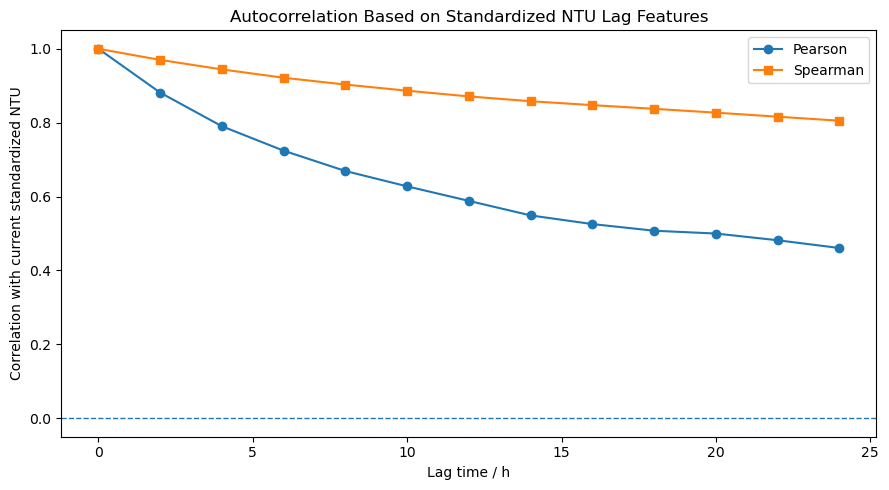

Saved: outputs\problem1\ntu_standardized_lag_autocorrelation_curve.png


In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    ntu_autocorr_df["lag_hours"],
    ntu_autocorr_df["pearson_corr"],
    marker="o",
    label="Pearson"
)

plt.plot(
    ntu_autocorr_df["lag_hours"],
    ntu_autocorr_df["spearman_corr"],
    marker="s",
    label="Spearman"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Lag time / h")
plt.ylabel("Correlation with current standardized NTU")
plt.title("Autocorrelation Based on Standardized NTU Lag Features")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "ntu_standardized_lag_autocorrelation_curve.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

### 4. 指定预测日期的 NTU 滞后项可用性检查

虽然历史 `NTU` 可能对当前 `NTU` 有预测价值，但题目要求预测 2026-02-01、2026-02-10 和 2026-02-20 的出厂水浊度。如果这些日期中的 `NTU` 本身缺失，那么当天后续时间点的 `NTU_lag1`、`NTU_lag2` 等也可能无法直接获得。

因此，本节检查指定三天中常用 `NTU` 滞后项的可用性。如果这些滞后项大量缺失，则说明 `NTU_lag` 不适合作为主模型的直接输入变量，只能作为扩展递推模型尝试。

In [8]:
target_dates = pd.to_datetime([
    "2026-02-01",
    "2026-02-10",
    "2026-02-20"
]).date

# 构造运行日期 OP_DATE
# 01:00、03:00、05:00 归属于前一天运行日
df["OP_DATE"] = df["DATETIME"].dt.date

early_morning_mask = df["DATETIME"].dt.hour < 7
df.loc[early_morning_mask, "OP_DATE"] = (
    df.loc[early_morning_mask, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

# 检查常用标准化 NTU 滞后项的可用性
check_lags = [1, 2, 3, 6, 12]

for lag in check_lags:
    if f"NTU_z_lag{lag}" not in df.columns:
        df[f"NTU_z_lag{lag}"] = df["NTU_z"].shift(lag)

target_ntu_lag_check = df[df["OP_DATE"].isin(target_dates)][
    ["OP_DATE", "DATETIME", "NTU", "NTU_z"] + [f"NTU_z_lag{lag}" for lag in check_lags]
].copy()

save_path = OUTPUT_DIR / "target_3days_standardized_ntu_lag_availability_by_opdate.csv"
target_ntu_lag_check.to_csv(save_path, index=False, encoding="utf-8-sig")

print("Saved:", save_path)

print("Rows per OP_DATE:")
print(target_ntu_lag_check["OP_DATE"].value_counts().sort_index())

print("\nMissing count in target 3 operating days:")
print(target_ntu_lag_check.isna().sum())

target_ntu_lag_check

Saved: outputs\problem1\target_3days_standardized_ntu_lag_availability_by_opdate.csv
Rows per OP_DATE:
OP_DATE
2026-02-01    12
2026-02-10    12
2026-02-20    12
Name: count, dtype: int64

Missing count in target 3 operating days:
OP_DATE         0
DATETIME        0
NTU            36
NTU_z          36
NTU_z_lag1     35
NTU_z_lag2     34
NTU_z_lag3     33
NTU_z_lag6     30
NTU_z_lag12    24
dtype: int64


,OP_DATE,DATETIME,NTU,NTU_z,NTU_z_lag1,NTU_z_lag2,NTU_z_lag3,NTU_z_lag6,NTU_z_lag12
4752,2026-02-01,2026-02-01 07:00:00,NaN,NaN,-0.204109,-0.204109,-0.204109,-0.155432,-0.187883
4753,2026-02-01,2026-02-01 09:00:00,NaN,NaN,NaN,-0.204109,-0.204109,-0.171658,-0.155432
4754,2026-02-01,2026-02-01 11:00:00,NaN,NaN,NaN,NaN,-0.204109,-0.171658,-0.187883
4755,2026-02-01,2026-02-01 13:00:00,NaN,NaN,NaN,NaN,NaN,-0.204109,-0.171658
4756,2026-02-01,2026-02-01 15:00:00,NaN,NaN,NaN,NaN,NaN,-0.204109,-0.171658
4757,2026-02-01,2026-02-01 17:00:00,NaN,NaN,NaN,NaN,NaN,-0.204109,-0.155432
4758,2026-02-01,2026-02-01 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-0.155432
4759,2026-02-01,2026-02-01 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-0.171658
4760,2026-02-01,2026-02-01 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-0.171658
4761,2026-02-01,2026-02-02 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-0.204109


### 5. NTU 自相关分析小结

NTU 自相关分析用于判断出厂水浊度自身是否具有时间连续性。若 `lag1`、`lag2` 等短滞后项与当前 `NTU` 具有较高相关性，说明出厂水浊度在相邻时间点之间存在一定延续性，当前状态可能受到前几个时刻状态的影响。

但需要注意的是，`NTU` 本身是题目要求预测的目标变量。在指定预测日期中，`NTU` 存在缺失，因此如果将 `NTU_lag1`、`NTU_lag2` 等直接作为模型输入，后续时间点可能需要依赖前一时刻的预测值，从而形成递推预测问题。该方法可作为扩展模型尝试，但不建议作为第一版主模型的核心输入。

因此，本节的主要作用是补充说明 `NTU` 的时间连续性，而最终 Selected-lag 模型仍优先使用 `FILT. NTU`、`CLR`、`R/W FLOW`、`T/W FLOW`、`C/W WELL LEVEL` 等可直接观测的外部变量。